In [1]:
pip install pandas matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd

orders = pd.read_csv('orders.csv')
payments = pd.read_csv('order_payments.csv')
customers = pd.read_csv('customers.csv')
order_items = pd.read_csv('order_items.csv')
products = pd.read_csv('products.csv')

In [4]:
df = orders.merge(payments, on='order_id') \
           .merge(customers, on='customer_id') \
           .merge(order_items, on='order_id') \
           .merge(products, on='product_id')

In [5]:
df.info()
df.isnull().sum()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 117601 entries, 0 to 117600
Data columns (total 30 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       117601 non-null  object 
 1   customer_id                    117601 non-null  object 
 2   order_status                   117601 non-null  object 
 3   order_purchase_timestamp       117601 non-null  object 
 4   order_approved_at              117586 non-null  object 
 5   order_delivered_carrier_date   116356 non-null  object 
 6   order_delivered_customer_date  115034 non-null  object 
 7   order_estimated_delivery_date  117601 non-null  object 
 8   payment_sequential             117601 non-null  int64  
 9   payment_type                   117601 non-null  object 
 10  payment_installments           117601 non-null  int64  
 11  payment_value                  117601 non-null  float64
 12  customer_unique_id            

,payment_sequential,payment_installments,payment_value,customer_zip_code_prefix,order_item_id,price,freight_value,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,117601.000000,117601.000000,117601.000000,117601.000000,117601.000000,117601.000000,117601.000000,115903.000000,115903.000000,115903.000000,117581.000000,117581.000000,117581.000000,117581.000000
mean,1.093528,2.939482,172.686752,35051.793097,1.195900,120.824783,20.045990,48.767590,786.950855,2.207881,2114.309497,30.257235,16.630306,23.068574
std,0.726692,2.774223,267.592290,29820.588877,0.697706,184.479323,15.861315,10.035011,653.036231,1.719531,3788.798201,16.190920,13.458952,11.748468
min,1.000000,0.000000,0.000000,1003.000000,1.000000,0.850000,0.000000,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,1.000000,1.000000,60.870000,11310.000000,1.000000,39.900000,13.080000,42.000000,347.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,1.000000,2.000000,108.210000,24315.000000,1.000000,74.900000,16.290000,52.000000,601.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,1.000000,4.000000,189.260000,58600.000000,1.000000,134.900000,21.190000,57.000000,985.000000,3.000000,1800.000000,38.000000,20.000000,30.000000
max,29.000000,24.000000,13664.080000,99990.000000,21.000000,6735.000000,409.680000,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000


In [6]:
df.groupby('product_category_name')['payment_value'].sum().sort_values(ascending=False).head(10)

product_category_name
cama_mesa_banho           1712553.67
beleza_saude              1657373.12
informatica_acessorios    1585330.45
moveis_decoracao          1430176.39
relogios_presentes        1429216.68
esporte_lazer             1392127.56
utilidades_domesticas     1094758.13
automotivo                 852294.33
ferramentas_jardim         838280.75
cool_stuff                 779698.00
Name: payment_value, dtype: float64

<Axes: xlabel='month'>

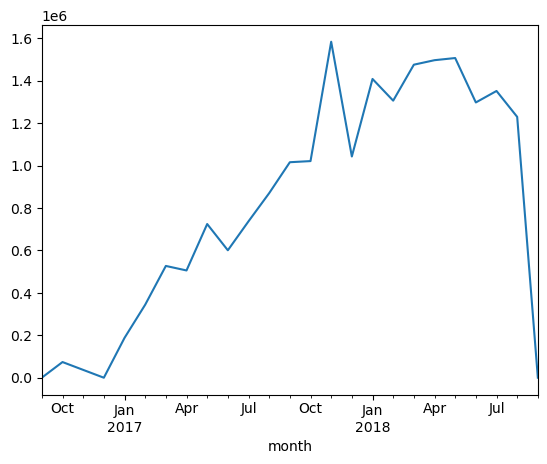

In [7]:
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])

df['month'] = df['order_purchase_timestamp'].dt.to_period('M')

df.groupby('month')['payment_value'].sum().plot()